# Project 8 — ICAAP Stress Testing
## Major European G-SIB | Severe But Plausible Scenario | Section 17

**Author:** Hossam Eltarrass  
**Model Version:** MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx — Section 17  
**Regulatory Framework:** CRD V Art.73 (ICAAP) | Basel III Pillar 2 | EBA/GL/2021/05  
**Reference Year:** 2026F  

---

### What is this notebook?

The **ICAAP** (Internal Capital Adequacy Assessment Process) is the bank's own self-assessment 
of whether it holds enough capital and liquidity to survive a **severe but plausible** stress 
scenario. It is required under Basel III / CRD V (Art.73) and submitted annually to the ECB 
for review as part of the **SREP** (Supervisory Review and Evaluation Process).

This notebook rebuilds the **ICAAP Stress Summary Engine** — the single ALCO-ready table that 
stress-tests all six key regulatory metrics simultaneously under one unified severe shock:

| Metric | What it captures |
|---|---|
| **NII** | Earnings sensitivity to rate + volume shock |
| **Net Income** | P&L viability after costs, provisions and tax |
| **CET1 Ratio** | Capital adequacy under stressed RWA and retained earnings |
| **LCR** | 30-day liquidity survival under deposit run |
| **NSFR** | Structural funding stability under deposit outflow |
| **EVE / Tier 1** | Economic value loss from +300bps rate shock |

Each metric links back to a prior project in this ALM series:  
**NII → P1 | CET1 → P1/P7 | LCR/NSFR → P3 | EVE → P2/P7**

---

### Severe Stress Scenario Parameters (Section 17)

| Parameter | Base 2026F | **Severe Stress** | Source |
|---|---|---|---|
| Rate Shock | 0 bps | **+300 bps** | ECB adverse scenario |
| Loan Growth | +3% | **−5%** | Credit contraction |
| Deposit Outflow | +2.5% | **−15%** | Behavioural stress |
| Cost of Risk | 25 bps | **100 bps** | Credit deterioration |
| Cost / Income Ratio | 62% | **70%** | Revenue + cost shock |

**Traffic light thresholds:** CET1 ≥ 13.5% | LCR ≥ 100% | NSFR ≥ 100% | EVE/T1 < 15%

In [1]:
# ============================================================
# CELL 2 — IMPORTS AND ALL MODEL PARAMETERS
# ============================================================
# All numbers sourced from MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx
# Cross-reference: Section 17 (Model sheet rows 331-353) + Engine sheet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ─── PROFESSIONAL CHART STYLE ─────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.grid': True,
    'grid.color': '#DDDDDD',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ─── SECTION 17 SEVERE STRESS PARAMETERS ──────────────────
# Source: Model!D335:D339
RATE_SHOCK_BPS   = 300          # +300bps — ECB adverse scenario
LOAN_GROWTH      = -0.05        # −5% loan contraction
DEP_OUTFLOW      = -0.15        # −15% net deposit outflow
COR_BPS          = 100          # 100bps Cost of Risk (vs base 25bps)
CIR_SEVERE       = 0.70         # 70% Cost/Income Ratio (vs base 62%)
DEP_BETA         = 0.60         # Deposit beta — Stress(4) scenario (Engine!F10)

# ─── MARKET RATE ENVIRONMENT ──────────────────────────────
# Source: Engine rows 14-17 (A2 — Market Rate Environment)
ECB_2026F        = 0.0225       # ECB DFR 2026F forecast (Engine!E14)
EURIBOR_2026F    = 0.0235       # 3M Euribor 2026F (Engine!E15)
SWAP10Y_2026F    = 0.0255       # 10Y Swap 2026F (Engine!E17)
ECB_2025A        = 0.025        # ECB DFR 2025A actual (Engine!D14)
EURIBOR_2025A    = 0.026        # 3M Euribor 2025A actual (Engine!D15)

# ─── SPREAD ASSUMPTIONS ───────────────────────────────────
# Source: Engine rows 23-30 (A3 — Spread Assumptions)
LOAN_BETA        = 0.90         # Loan repricing beta (Engine!C24)
IB_SPREAD        = 0.005        # Interbank spread over Euribor (Engine!E27)
BOND_PORT_SPREAD = 0.004        # Securities yield spread over 10Y swap (Engine!E26)
REPO_SPREAD      = -0.00085     # Repo spread below ECB DFR (Engine!E28)
BOND_ISS_SPREAD  = 0.0065       # Senior unsecured bonds over 10Y swap (Engine!E29)
SUB_DEBT_COST    = 0.025        # Sub debt blended cost — fixed (Engine!E30)

# ─── 2025A RATES (baseline for repricing formula) ─────────
# Source: Engine rows 116-117
LOAN_YIELD_2025A = 0.038        # Loan yield 2025A (Engine!D116)
DEP_RATE_2025A   = 0.005        # Deposit rate 2025A (Engine!D117)

# ─── BALANCE SHEET — 2025A (used in ICAAP volume formula) ─
# Source: Engine rows 128-145 (D column = 2025A)
LOANS_2025A      = 897_358      # Customer loans 2025A €m (Engine!D128)
DEPOSITS_2025A   = 1_075_564    # Customer deposits 2025A €m (Engine!D136)
IB_LOANS_2025A   = 26_259       # Interbank loans 2025A €m (Engine!D129)
IB_FUND_2025A    = 69_938       # Interbank funding 2025A €m (Engine!D137)
REPO_2025A       = 357_947      # Repo funding 2025A €m (Engine!D138)
BONDS_ISS_2025A  = 173_933      # Bonds issued 2025A €m (Engine!D139)
SUB_DEBT_2025A   = 34_468       # Subordinated debt 2025A €m (Engine!D140)
EQUITY_2025A     = 132_173      # Equity / Tier 1 proxy 2025A €m (Engine!D145)

# ─── BALANCE SHEET — 2026F (for items that don't grow with loans) ─
# Source: Engine rows 126-132 (E column = 2026F)
CASH_2026F       = 214_325.33   # Cash & CB reserves 2026F €m (Engine!E126)
SECURITIES_2026F = 157_700.21   # Securities portfolio 2026F €m (Engine!E130)
TRADING_2026F    = 870_245      # Trading assets 2026F €m (Engine!E127)
TOTAL_ASSETS_2026F = 2_833_837.10  # Total assets 2026F €m (Engine!E132)

# ─── P&L PARAMETERS ───────────────────────────────────────
FEE_RATIO        = 0.008        # Fee income as % total assets (Engine!C40)
TAX_RATE         = 0.25         # French corporate tax rate (Engine!C156)
PAYOUT_RATIO     = 0.60         # Dividend payout (Engine!C41)

# ─── CAPITAL (RWA RISK WEIGHTS) ───────────────────────────
# Source: Engine Section 7 formula (Model!E346)
RW_LOANS         = 0.75         # Customer loans risk weight
RW_SECURITIES    = 0.20         # Securities portfolio risk weight
RW_IB_LOANS      = 0.20         # Interbank loans risk weight
RW_TRADING       = 0.15         # Trading book risk weight (Engine!C190 SA-TB)

# ─── LCR DATA (2026F, from Model Section 5, D column) ─────
# Source: Model rows 69-93
HQLA_2026F             = 365_402.13   # Total HQLA 2026F €m (Model!D74)
TOTAL_OUTFLOWS_2026F   = 300_579.55   # Total 30-day gross outflows €m (Model!D85)
STABLE_DEP_OUT_2026F   =  38_585.86   # Stable deposit outflows €m (Model!D77)
LESS_STABLE_DEP_2026F  =  33_073.59   # Less stable deposit outflows €m (Model!D78)
TOTAL_INFLOWS_2026F    =  62_607.41   # Total inflows (capped) €m (Model!D90)
INFLOW_CAP_PCT         = 0.75         # Inflow cap (Engine!C71)

# ─── NSFR DATA (2026F, from Model Section 6) ──────────────
# Source: Model rows 96-122
ASF_2026F        = 1_322_746.31  # Total Available Stable Funding 2026F €m (Model!F106)
RSF_2026F        = 1_377_568.59  # Total Required Stable Funding 2026F €m (Model!F121)
NMD_STABLE_PCT   = 0.70          # NMD stable deposit proportion (Engine!C36)
NMD_NONSTABLE_PCT = 0.30         # NMD non-core proportion (Engine!C37)
ASF_STABLE       = 0.90          # Stable deposits ASF factor (Engine!C76)
ASF_NONSTABLE    = 0.80          # Less stable deposits ASF factor (Engine!C77)

# ─── EVE / IRRBB DATA (from Section 14, PVBP) ────────────
# Source: Model!E222 — PVBP from Section 14 full discounting
PVBP             = -194.5093     # Price Value of a Basis Point €m/bp (Model!E222)
HEDGE_RATIO      = 0.55          # IRS hedge ratio (Engine!C256)
TIER1_CAPITAL    = EQUITY_2025A  # Tier 1 proxy = CET1 2025A equity (Engine!D145)

# ─── REGULATORY THRESHOLDS ────────────────────────────────
# Source: Engine rows 93-102 (A8 — Regulatory Thresholds)
CET1_MIN         = 0.135         # CRR Art.92 P1+Buffers+P2R+G-SII+CCyB
LCR_MIN          = 1.00          # Del. Reg. (EU) 2022/786 Art.4
NSFR_MIN         = 1.00          # CRR Art.428b (CRR2)
EVE_OUTLIER      = 0.15          # EBA/GL/2022/14 para 114 — outlier test
NII_EWI_PCT      = 0.10          # >10% decline triggers Early Warning Indicator

print("✓ Parameters loaded")
print(f"  Rate shock: +{RATE_SHOCK_BPS}bps | Loan growth: {LOAN_GROWTH*100:.0f}% | Deposit outflow: {DEP_OUTFLOW*100:.0f}%")
print(f"  CoR: {COR_BPS}bps | CIR: {CIR_SEVERE*100:.0f}% | Dep beta: {DEP_BETA}")

✓ Parameters loaded
  Rate shock: +300bps | Loan growth: -5% | Deposit outflow: -15%
  CoR: 100bps | CIR: 70% | Dep beta: 0.6


## Part A — Stressed P&L Engine
### Step 1: Stressed NII and Net Income

**Formula logic (sourced from Engine!C195-C198 + Model!E344-E345):**

The NII engine reprices each balance sheet item using the market rate movement from 2025A → 2026F plus the +300bps shock, weighted by each item's repricing sensitivity (beta):

```
Loan yield severe  = Loan yield 2025A + Loan beta × (Euribor_2026F + shock − Euribor_2025A)
Deposit rate severe = max(0, Dep rate 2025A + Dep beta × (ECB_2026F + shock − ECB_2025A))
```

**Stressed volumes (from Section 17 D336/D337):**
- Loans: €897,358m × 0.95 = €852,490m (2025A balance × −5%)
- Deposits: €1,075,564m × 0.85 = €914,229m (2025A balance × −15%)

**Net Income** = (Revenue × (1 − CIR) − Provisions) × (1 − Tax)

**Why does Net Income stay GREEN despite the shock?**  
The +300bps rate shock simultaneously raises asset income. Even with 100bps CoR and 70% CIR, the repricing gain on €852bn of floating-rate loans is powerful enough to keep the bank profitable — barely.

In [1]:
# ============================================================
# CELL 4 — STRESSED NII + NET INCOME ENGINE
# ============================================================
# Formula: Model!E344 (NII) and Model!E345 (Net Income)
# Methodology: Section 17 — rebuild from Section 2 formula
# with stressed volumes (D column = 2025A base) and shocked rates

# ─── STEP 1: STRESSED BALANCE SHEET VOLUMES ───────────────
loans_sev    = LOANS_2025A   * (1 + LOAN_GROWTH)   # 897,358 × 0.95 = 852,490.10m
deposits_sev = DEPOSITS_2025A * (1 + DEP_OUTFLOW)  # 1,075,564 × 0.85 = 914,229.40m

# ─── STEP 2: STRESSED RATES ───────────────────────────────
shock = RATE_SHOCK_BPS / 10_000   # Convert bps → decimal (300bps = 0.0300)

# Loan yield: 2025A base + loan beta × (Euribor change + shock)
# Formula: D116 + C24 × ((E15 + C10/10000) − D15)
loan_yield_sev = LOAN_YIELD_2025A + LOAN_BETA * ((EURIBOR_2026F + shock) - EURIBOR_2025A)

# Deposit rate: 2025A base + deposit beta × (ECB change + shock), floor at 0%
# Formula: MAX(0, D117 + F10 × ((E14 + C10/10000) − D14))
dep_rate_sev = max(0, DEP_RATE_2025A + DEP_BETA * ((ECB_2026F + shock) - ECB_2025A))

# Other shocked rates (floating items reprice with market rate + shock)
ib_rate_sev       = EURIBOR_2026F + shock + IB_SPREAD       # Interbank: Euribor + shock + spread
securities_yld_sev = SWAP10Y_2026F + shock + BOND_PORT_SPREAD # Securities: 10Y swap + shock + spread
repo_rate_sev     = ECB_2026F + shock + REPO_SPREAD          # Repo: ECB + shock + repo spread
bond_iss_rate_sev = SWAP10Y_2026F + shock + BOND_ISS_SPREAD  # Bonds issued: 10Y swap + shock + spread
# Sub debt is FIXED — does not reprice

print("─── Stressed Rates ───────────────────────────────")
print(f"  Loan yield:         {loan_yield_sev*100:.3f}%  (base 3.575%  → +{(loan_yield_sev-0.03575)*100:.3f}pp)")
print(f"  Deposit rate:       {dep_rate_sev*100:.3f}%  (base 0.400%  → +{(dep_rate_sev-0.004)*100:.3f}pp)")
print(f"  Interbank rate:     {ib_rate_sev*100:.3f}%")
print(f"  Securities yield:   {securities_yld_sev*100:.3f}%")
print(f"  Repo rate:          {repo_rate_sev*100:.3f}%")
print(f"  Bonds issued rate:  {bond_iss_rate_sev*100:.3f}%")
print(f"  Sub debt rate:      {SUB_DEBT_COST*100:.3f}%  (FIXED — no reprice)")

# ─── STEP 3: NII CALCULATION ──────────────────────────────
# ASSET INCOME
# Note: Cash earns ECB DFR 2026F — not repriced in this formula (Model!E344 uses E14 without shock)
income_cash        = CASH_2026F    * ECB_2026F           # Cash at CB earns base DFR 2026F
income_loans       = loans_sev     * loan_yield_sev      # Stressed loans × stressed loan yield
income_ib_loans    = IB_LOANS_2025A * ib_rate_sev        # IB loans × shocked Euribor + spread
income_securities  = SECURITIES_2026F * securities_yld_sev # Securities × shocked 10Y + spread

total_income = income_cash + income_loans + income_ib_loans + income_securities

# LIABILITY COSTS
cost_deposits   = deposits_sev   * dep_rate_sev          # Stressed deposits × stressed deposit rate
cost_ib_fund    = IB_FUND_2025A  * ib_rate_sev           # IB funding × shocked rate
cost_repo       = REPO_2025A     * repo_rate_sev          # Repo × shocked ECB + spread
cost_bonds_iss  = BONDS_ISS_2025A * bond_iss_rate_sev    # Bonds issued × shocked rate
cost_sub_debt   = SUB_DEBT_2025A * SUB_DEBT_COST         # Sub debt is fixed — no shock

total_cost = cost_deposits + cost_ib_fund + cost_repo + cost_bonds_iss + cost_sub_debt

NII_severe = total_income - total_cost
NII_base   = 22_685.67   # Model!D344 — Base 2026F NII

print("\n─── NII Build-Up (€m) ─────────────────────────────")
print(f"  Cash income:          {income_cash:>10,.1f}")
print(f"  Loan income:          {income_loans:>10,.1f}")
print(f"  IB loan income:       {income_ib_loans:>10,.1f}")
print(f"  Securities income:    {income_securities:>10,.1f}")
print(f"  TOTAL INCOME:         {total_income:>10,.1f}")
print(f"  Deposit cost:         {cost_deposits:>10,.1f}")
print(f"  IB funding cost:      {cost_ib_fund:>10,.1f}")
print(f"  Repo cost:            {cost_repo:>10,.1f}")
print(f"  Bond issuance cost:   {cost_bonds_iss:>10,.1f}")
print(f"  Sub debt cost:        {cost_sub_debt:>10,.1f}")
print(f"  TOTAL COST:           {total_cost:>10,.1f}")
print(f"  ─────────────────────────────────────────────")
print(f"  ★ NII SEVERE:         {NII_severe:>10,.1f}")
print(f"    Base NII 2026F:     {NII_base:>10,.1f}")
print(f"    ΔNII:               {NII_severe-NII_base:>10,.1f}  ({(NII_severe-NII_base)/NII_base*100:.1f}%)")

# ─── STEP 4: NET INCOME CALCULATION ───────────────────────
# Formula: Model!E345 =((E344 + E132×C40)×(1−D339) − D128×(1+D336)×D338/10000)×(1−C156)
fee_income   = TOTAL_ASSETS_2026F * FEE_RATIO            # Fee income uses 2026F total assets
revenue      = NII_severe + fee_income                   # Total revenue = NII + fees
provisions   = loans_sev * COR_BPS / 10_000             # Loan loss provisions = CoR × stressed loans
pre_tax      = revenue * (1 - CIR_SEVERE) - provisions  # Pre-tax income
NI_severe    = pre_tax * (1 - TAX_RATE)                  # Net income after 25% tax
NI_base      = 11_193.54   # Model!D345 — Base Net Income 2026F

print("\n─── Net Income Build-Up (€m) ───────────────────────")
print(f"  NII severe:           {NII_severe:>10,.1f}")
print(f"  Fee income:           {fee_income:>10,.1f}  ({FEE_RATIO*100:.1f}% × total assets)")
print(f"  Total revenue:        {revenue:>10,.1f}")
print(f"  Operating expenses:   {-revenue*CIR_SEVERE:>10,.1f}  (CIR {CIR_SEVERE*100:.0f}%)")
print(f"  Provisions (CoR):     {-provisions:>10,.1f}  ({COR_BPS}bps × €{loans_sev/1000:.0f}bn loans)")
print(f"  Pre-tax income:       {pre_tax:>10,.1f}")
print(f"  Tax (25%):            {-pre_tax*TAX_RATE:>10,.1f}")
print(f"  ─────────────────────────────────────────────")
print(f"  ★ NET INCOME SEVERE:  {NI_severe:>10,.1f}")
print(f"    Base Net Income:    {NI_base:>10,.1f}")
print(f"    ΔNet Income:        {NI_severe-NI_base:>10,.1f}")

─── Stressed Rates ───────────────────────────────
  Loan yield:         6.275%  (base 3.575%  → +2.700pp)
  Deposit rate:       2.150%  (base 0.400%  → +1.750pp)
  Interbank rate:     5.850%
  Securities yield:   5.950%
  Repo rate:          5.165%
  Bonds issued rate:  6.200%
  Sub debt rate:      2.500%  (FIXED — no reprice)

─── NII Build-Up (€m) ─────────────────────────────
  Cash income:             4,822.3
  Loan income:            53,493.8
  IB loan income:          1,536.2
  Securities income:       9,383.2
  TOTAL INCOME:           69,235.4
  Deposit cost:           19,655.9
  IB funding cost:         4,091.4
  Repo cost:              18,488.0
  Bond issuance cost:     10,783.8
  Sub debt cost:             861.7
  TOTAL COST:             53,880.8
  ─────────────────────────────────────────────
  ★ NII SEVERE:           15,354.6
    Base NII 2026F:       22,685.7
    ΔNII:                 -7,331.1  (-32.3%)

─── Net Income Build-Up (€m) ───────────────────────
  NII severe:  

In [1]:
# ============================================================
# CELL 5 — CET1 RATIO ENGINE
# ============================================================
# Formula: Model!E346
# = (D145 + E345×(1−C41)) / (Loans_sev×0.75 + Securities×0.20 + IB×0.20 + Trading×0.15)
#
# CET1 formula logic:
#   Numerator   = Equity 2025A + Retained Earnings from stressed P&L
#   Denominator = Risk-Weighted Assets under stressed balance sheet
#
# Why does CET1 IMPROVE under severe stress?
#   − Loan contraction (−5%) shrinks RWA significantly
#   − +300bps rate shock still generates positive Net Income → adds retained earnings
#   − Combined effect: RWA falls faster than equity
#   This is the key P2 insight: short-run NII benefit from rate hike vs long-run EVE damage

# ─── STEP 1: STRESSED EQUITY ──────────────────────────────
retained_earnings_sev = NI_severe * (1 - PAYOUT_RATIO)   # 40% of Net Income retained
equity_severe         = EQUITY_2025A + retained_earnings_sev

# ─── STEP 2: STRESSED RWA ─────────────────────────────────
# Risk-weighted assets driven by stressed loan balance
rwa_loans       = loans_sev          * RW_LOANS        # 75% risk weight on customer loans
rwa_securities  = SECURITIES_2026F   * RW_SECURITIES   # 20% risk weight on securities
rwa_ib_loans    = IB_LOANS_2025A     * RW_IB_LOANS     # 20% risk weight on interbank loans
rwa_trading     = TRADING_2026F      * RW_TRADING      # 15% SA-TB weight on trading book
RWA_severe      = rwa_loans + rwa_securities + rwa_ib_loans + rwa_trading

# ─── STEP 3: CET1 RATIO ───────────────────────────────────
CET1_severe = equity_severe / RWA_severe
CET1_base   = 0.1588   # Model!D346 — Base CET1 2026F (15.88%)
RWA_base    = 860_537.65  # Engine!C246 — Base RWA 2026F

print("─── CET1 Build-Up ──────────────────────────────────")
print(f"  Equity 2025A:         {EQUITY_2025A:>10,.1f} €m")
print(f"  Retained earnings:    {retained_earnings_sev:>10,.1f} €m  (40% × €{NI_severe:.0f}m)")
print(f"  Stressed equity:      {equity_severe:>10,.1f} €m")
print()
print(f"  RWA — Loans:          {rwa_loans:>10,.1f} €m  ({RW_LOANS*100:.0f}% × €{loans_sev/1000:.0f}bn)")
print(f"  RWA — Securities:     {rwa_securities:>10,.1f} €m  ({RW_SECURITIES*100:.0f}%)")
print(f"  RWA — IB Loans:       {rwa_ib_loans:>10,.1f} €m  ({RW_IB_LOANS*100:.0f}%)")
print(f"  RWA — Trading:        {rwa_trading:>10,.1f} €m  ({RW_TRADING*100:.0f}% SA-TB)")
print(f"  TOTAL RWA severe:     {RWA_severe:>10,.1f} €m")
print(f"  Base RWA 2026F:       {RWA_base:>10,.1f} €m")
print(f"  ΔRWA:                 {RWA_severe-RWA_base:>10,.1f} €m")
print(f"  ─────────────────────────────────────────────")
print(f"  ★ CET1 SEVERE:        {CET1_severe*100:>10.2f}%")
print(f"    Base CET1:          {CET1_base*100:>10.2f}%")
print(f"    ΔCET1:              {(CET1_severe-CET1_base)*100:>10.2f}pp")
print(f"    Reg. minimum:       {CET1_MIN*100:>10.1f}%")
print(f"    Buffer above min:   {(CET1_severe-CET1_MIN)*100:>10.2f}pp")

─── CET1 Build-Up ──────────────────────────────────
  Equity 2025A:          132,173.0 €m
  Retained earnings:         864.8 €m  (40% × €2162m)
  Stressed equity:       133,037.8 €m

  RWA — Loans:           639,367.6 €m  (75% × €852bn)
  RWA — Securities:       31,540.0 €m  (20%)
  RWA — IB Loans:          5,251.8 €m  (20%)
  RWA — Trading:         130,536.8 €m  (15% SA-TB)
  TOTAL RWA severe:      806,696.2 €m
  Base RWA 2026F:        860,537.7 €m
  ΔRWA:                  -53,841.5 €m
  ─────────────────────────────────────────────
  ★ CET1 SEVERE:             16.49%
    Base CET1:               15.88%
    ΔCET1:                    0.61pp
    Reg. minimum:             13.5%
    Buffer above min:         2.99pp


In [1]:
# ============================================================
# CELL 6 — LCR AND NSFR STRESS ENGINE
# ============================================================

# ─────────────────────────────────────────────────────────────
# PART A: LCR STRESS
# Formula: Model!E347
# = D74 / (D136×|D337| + (D85−D77−D78) − MIN(D90, (D136×|D337|+(D85−D77−D78))×C71))
#
# Logic:
#   The ICAAP replaces the standard deposit outflow rates with a flat 15% outflow
#   on the FULL deposit book (2025A balance). All other outflows (repo, IB, undrawn
#   facilities) remain at base 2026F levels. HQLA is unchanged (cash + govt bonds
#   held as buffer). The inflow cap (75% of gross outflows) prevents perverse results.
#
# Key: HQLA stays robust at €365bn. The shock is purely on the OUTFLOW side.
# ─────────────────────────────────────────────────────────────

# Deposit outflow: 15% of 2025A deposits (flat rate, replaces LCR runoff tiers)
deposit_outflow_icaap = DEPOSITS_2025A * abs(DEP_OUTFLOW)   # 1,075,564 × 15% = 161,335

# Non-deposit outflows: repo + IB + undrawn facilities + CB (exclude deposit buckets from base)
non_deposit_outflows = TOTAL_OUTFLOWS_2026F - STABLE_DEP_OUT_2026F - LESS_STABLE_DEP_2026F

# Stressed gross outflows = new deposit outflow + unchanged non-deposit outflows
stressed_gross_outflows = deposit_outflow_icaap + non_deposit_outflows

# Inflow cap: 75% of gross outflows (Art.33 mandatory cap)
inflow_cap = min(TOTAL_INFLOWS_2026F, stressed_gross_outflows * INFLOW_CAP_PCT)

# Net stressed outflows = gross outflows − capped inflows
net_stressed_outflows = stressed_gross_outflows - inflow_cap

LCR_severe = HQLA_2026F / net_stressed_outflows
LCR_base   = 1.5355   # Model!D347 — Base LCR 2026F (153.55%)

print("─── LCR Build-Up ───────────────────────────────────")
print(f"  HQLA (2026F):          {HQLA_2026F:>10,.1f} €m  (L1 cash + govt + L2A corp)")
print()
print(f"  Deposit outflow 15%:   {deposit_outflow_icaap:>10,.1f} €m  (flat run-off on €{DEPOSITS_2025A/1000:.0f}bn)")
print(f"  Non-deposit outflows:  {non_deposit_outflows:>10,.1f} €m  (repo + IB + undrawn)")
print(f"  Gross stressed out.:   {stressed_gross_outflows:>10,.1f} €m")
print(f"  Inflow cap (75%):      {-inflow_cap:>10,.1f} €m")
print(f"  Net stressed outflows: {net_stressed_outflows:>10,.1f} €m")
print(f"  Base net outflows:     {237_972.14:>10,.1f} €m")
print(f"  ─────────────────────────────────────────────")
print(f"  ★ LCR SEVERE:         {LCR_severe*100:>10.2f}%")
print(f"    Base LCR 2026F:     {LCR_base*100:>10.2f}%")
print(f"    ΔLCR:               {(LCR_severe-LCR_base)*100:>10.2f}pp")
print(f"    Reg. minimum:       {LCR_MIN*100:>10.1f}%")
print()

# ─────────────────────────────────────────────────────────────
# PART B: NSFR STRESS
# Formula: Model!E348
# = (F106 − D136×|D337|×(0.7×C76+0.3×C77)) / F121
#
# Logic:
#   The ICAAP removes the ASF contribution from deposits that run off.
#   The 15% outflow is split 70%/30% stable/less stable (NMD model).
#   Stable deposits lose 90% ASF factor, less stable lose 80% ASF factor.
#   RSF is UNCHANGED (assets don't shrink in NSFR — structural mismatch remains).
#
# Key insight: NSFR was ALREADY below 100% in base 2026F (96.02%).
# Any deposit outflow pushes it deeper into breach territory.
# ─────────────────────────────────────────────────────────────

# ASF lost = deposit outflow × blended ASF factor
blended_asf_factor = NMD_STABLE_PCT * ASF_STABLE + NMD_NONSTABLE_PCT * ASF_NONSTABLE
asf_reduction = DEPOSITS_2025A * abs(DEP_OUTFLOW) * blended_asf_factor

asf_severe = ASF_2026F - asf_reduction
NSFR_severe = asf_severe / RSF_2026F
NSFR_base   = 0.9602   # Model!D348 — Base NSFR 2026F

print("─── NSFR Build-Up ──────────────────────────────────")
print(f"  Base ASF 2026F:        {ASF_2026F:>10,.1f} €m")
print(f"  Blended ASF factor:    {blended_asf_factor*100:>10.1f}%  (70%×90% + 30%×80%)")
print(f"  Deposit outflow:       {DEPOSITS_2025A*abs(DEP_OUTFLOW)/1000:>10.1f} €bn")
print(f"  ASF reduction:         {-asf_reduction:>10,.1f} €m")
print(f"  Stressed ASF:          {asf_severe:>10,.1f} €m")
print(f"  RSF (unchanged):       {RSF_2026F:>10,.1f} €m")
print(f"  ─────────────────────────────────────────────")
print(f"  ★ NSFR SEVERE:        {NSFR_severe*100:>10.2f}%")
print(f"    Base NSFR 2026F:    {NSFR_base*100:>10.2f}%  ← already below 100%!")
print(f"    ΔNSFR:              {(NSFR_severe-NSFR_base)*100:>10.2f}pp")
print(f"    Reg. minimum:       {NSFR_MIN*100:>10.1f}%")
print(f"    Breach:             {(NSFR_severe-NSFR_MIN)*100:>10.2f}pp below minimum")

─── LCR Build-Up ───────────────────────────────────
  HQLA (2026F):           365,402.1 €m  (L1 cash + govt + L2A corp)

  Deposit outflow 15%:    161,334.6 €m  (flat run-off on €1076bn)
  Non-deposit outflows:   228,920.1 €m  (repo + IB + undrawn)
  Gross stressed out.:    390,254.7 €m
  Inflow cap (75%):       -62,607.4 €m
  Net stressed outflows:  327,647.3 €m
  Base net outflows:      237,972.1 €m
  ─────────────────────────────────────────────
  ★ LCR SEVERE:             111.52%
    Base LCR 2026F:         153.55%
    ΔLCR:                   -42.03pp
    Reg. minimum:            100.0%

─── NSFR Build-Up ──────────────────────────────────
  Base ASF 2026F:        1,322,746.3 €m
  Blended ASF factor:          87.0%  (70%×90% + 30%×80%)
  Deposit outflow:            161.3 €bn
  ASF reduction:         -140,361.1 €m
  Stressed ASF:          1,182,385.2 €m
  RSF (unchanged):       1,377,568.6 €m
  ─────────────────────────────────────────────
  ★ NSFR SEVERE:             85.83%
    Ba

In [1]:
# ============================================================
# CELL 7 — EVE / TIER 1 STRESS ENGINE
# ============================================================
# Formula: Model!E349
# = ABS(E222 × D335 × (1 − C256)) / D145
#
# Logic:
#   EVE = the economic value impact of a parallel +300bps rate shock
#   applied to the full banking book cashflow structure.
#   The IRS hedge book (55% hedge ratio) absorbs part of the gross exposure.
#   PVBP = Price Value of a Basis Point from Section 14 full discounting.
#
#   EVE Severe = |PVBP × 300bps × (1 − hedge ratio)| / Tier 1
#
# Why is EVE RED even though Net Income is GREEN?
#   NII measures the NEXT 12 MONTHS of income → rate hike helps short-run.
#   EVE measures the FULL ECONOMIC LIFETIME of all cashflows → rate hike
#   destroys long-duration asset values faster than it benefits liability savings.
#   This is the fundamental ALM tension first seen in Project 2.

# ─── EVE CALCULATION ──────────────────────────────────────
gross_eve_impact = abs(PVBP * RATE_SHOCK_BPS)               # Gross EVE loss before hedge
hedge_offset     = gross_eve_impact * HEDGE_RATIO            # IRS hedge absorbs 55%
net_eve_impact   = gross_eve_impact * (1 - HEDGE_RATIO)      # Net EVE loss after hedge

EVE_T1_severe = net_eve_impact / TIER1_CAPITAL               # As % of Tier 1 capital
EVE_T1_base   = 0.1324   # Model!D349 — Base EVE/T1 (13.24% under Par Up +200bps)

print("─── EVE / Tier 1 Build-Up ──────────────────────────")
print(f"  PVBP (Section 14):     {PVBP:>10.4f} €m/bp")
print(f"  Rate shock:            +{RATE_SHOCK_BPS} bps")
print(f"  Gross EVE impact:      {gross_eve_impact:>10,.1f} €m")
print(f"  IRS hedge offset 55%:  {-hedge_offset:>10,.1f} €m")
print(f"  Net EVE impact:        {net_eve_impact:>10,.1f} €m")
print(f"  Tier 1 Capital:        {TIER1_CAPITAL:>10,.1f} €m")
print(f"  ─────────────────────────────────────────────")
print(f"  ★ EVE / T1 SEVERE:    {EVE_T1_severe*100:>10.2f}%")
print(f"    Base EVE / T1:      {EVE_T1_base*100:>10.2f}%  (Par Up +200bps)")
print(f"    ΔEVE/T1:            {(EVE_T1_severe-EVE_T1_base)*100:>10.2f}pp")
print(f"    Outlier threshold:  {EVE_OUTLIER*100:>10.1f}%")
print(f"    Breach:             {(EVE_T1_severe-EVE_OUTLIER)*100:>10.2f}pp above threshold ⚠")

─── EVE / Tier 1 Build-Up ──────────────────────────
  PVBP (Section 14):      -194.5093 €m/bp
  Rate shock:            +300 bps
  Gross EVE impact:        58,352.8 €m
  IRS hedge offset 55%:   -32,094.0 €m
  Net EVE impact:          26,258.8 €m
  Tier 1 Capital:         132,173.0 €m
  ─────────────────────────────────────────────
  ★ EVE / T1 SEVERE:         19.87%
    Base EVE / T1:           13.24%  (Par Up +200bps)
    ΔEVE/T1:                  6.63pp
    Outlier threshold:        15.0%
    Breach:                   4.87pp above threshold ⚠


════════════════════════════════════════════════════════════════════════════════
     ICAAP STRESS SUMMARY TABLE | ALCO-READY | Major European G-SIB | 2026F     
════════════════════════════════════════════════════════════════════════════════
Metric                 Reg. Min         Base 2026F  Severe Stress     Change  Traffic Light
────────────────────────────────────────────────────────────────────────────────
  NII (€m)             EWI: >−10%           22,686         15,355     -7,331  ● RED
  Net Income (€m)      >0                   11,194          2,162     -9,032  ● GREEN
  CET1 Ratio           ≥13.5%               15.88%         16.49%     +0.61%  ● GREEN
  LCR                  ≥100%               153.55%        111.52%    -42.03%  ● GREEN
  NSFR                 ≥100%                96.02%         85.83%    -10.19%  ● RED
  EVE / Tier 1         <15% (outlier)       13.24%         19.87%     +6.63%  ● RED
──────────────────────────────────────────────────────────────────────────

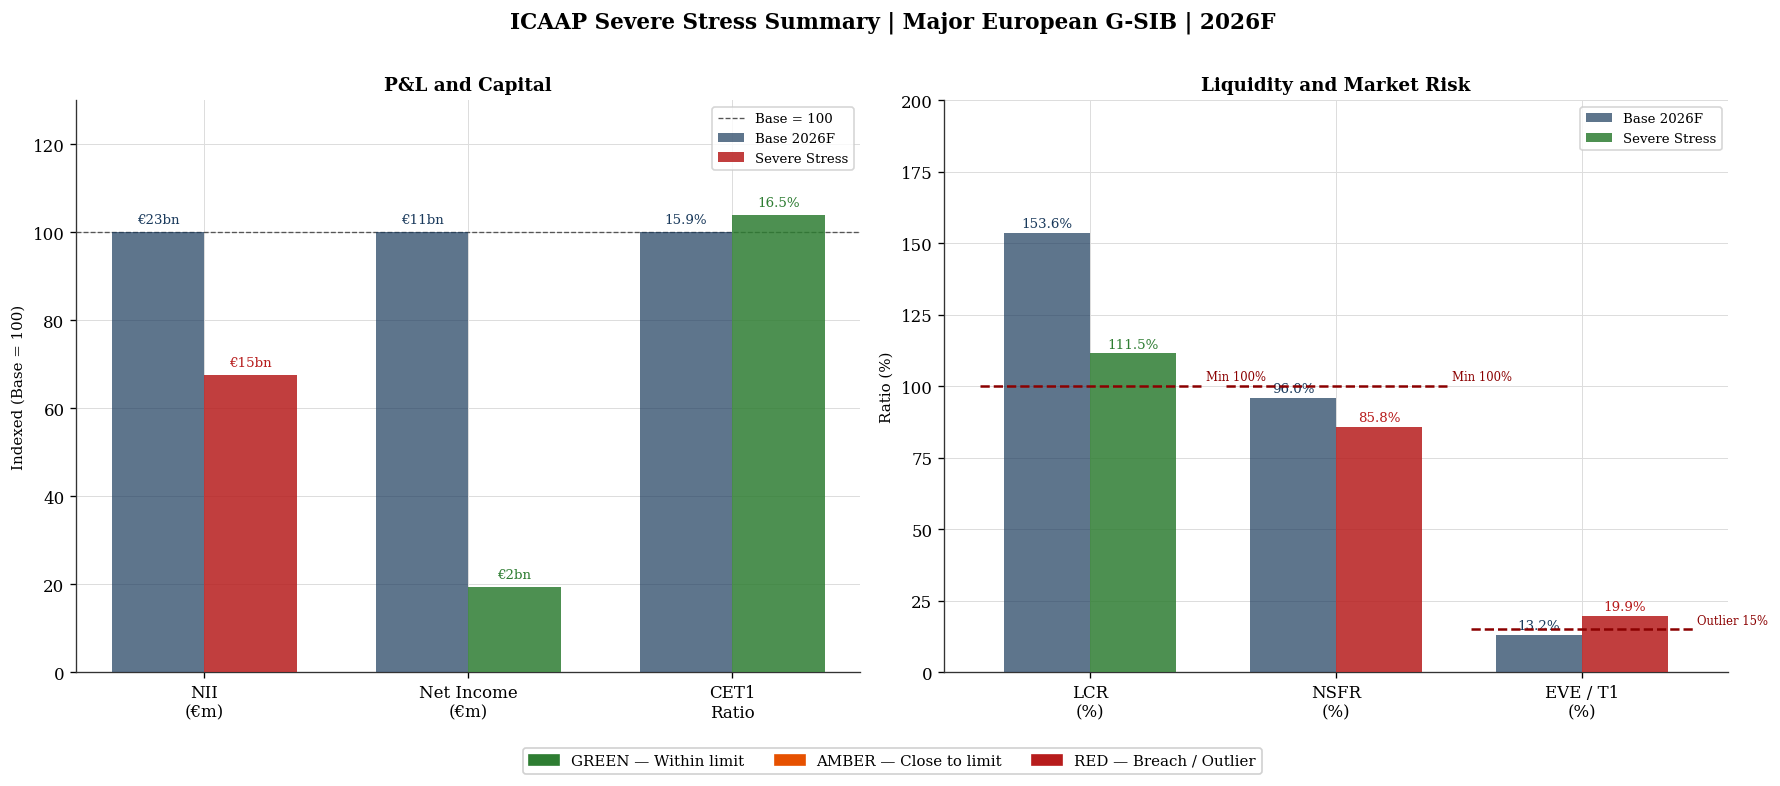

In [1]:
# ============================================================
# CELL 8 — ICAAP TRAFFIC LIGHT SUMMARY + DUAL CHART
# ============================================================

NII_change_pct = (NII_severe - NII_base) / NII_base * 100

# Traffic light functions (matching Excel Section 17 formulas)
def tl_nii(change_pct):
    if change_pct >= -10:  return 'GREEN'
    if change_pct >= -25:  return 'AMBER'
    return 'RED'

def tl_ni(ni):
    return 'GREEN' if ni >= 0 else 'RED'

def tl_cet1(ratio):
    if ratio >= CET1_MIN:  return 'GREEN'
    if ratio >= 0.10:      return 'AMBER'
    return 'RED'

def tl_lcr(ratio):
    if ratio >= LCR_MIN:  return 'GREEN'
    if ratio >= 0.80:     return 'AMBER'
    return 'RED'

def tl_nsfr(ratio):
    if ratio >= NSFR_MIN: return 'GREEN'
    if ratio >= 0.90:     return 'AMBER'
    return 'RED'

def tl_eve(ratio):
    return 'GREEN' if ratio <= EVE_OUTLIER else 'RED'

tl_colors  = {'GREEN': '#2E7D32', 'AMBER': '#E65100', 'RED': '#B71C1C'}
tl_symbols = {'GREEN': '● GREEN', 'AMBER': '● AMBER', 'RED': '● RED'}

# Results table: (metric, reg_min, base, severe, change, traffic_light, is_pct)
results = [
    ('NII (€m)',       'EWI: >−10%',     NII_base,     NII_severe,     NII_severe-NII_base,     tl_nii(NII_change_pct),  False),
    ('Net Income (€m)','>0',             NI_base,      NI_severe,      NI_severe-NI_base,       tl_ni(NI_severe),         False),
    ('CET1 Ratio',     '≥13.5%',         CET1_base,    CET1_severe,    CET1_severe-CET1_base,   tl_cet1(CET1_severe),     True),
    ('LCR',            '≥100%',          LCR_base,     LCR_severe,     LCR_severe-LCR_base,     tl_lcr(LCR_severe),       True),
    ('NSFR',           '≥100%',          NSFR_base,    NSFR_severe,    NSFR_severe-NSFR_base,   tl_nsfr(NSFR_severe),     True),
    ('EVE / Tier 1',   '<15% (outlier)', EVE_T1_base,  EVE_T1_severe,  EVE_T1_severe-EVE_T1_base, tl_eve(EVE_T1_severe),  True),
]

# ─── PRINT TABLE ──────────────────────────────────────────
print("═" * 80)
print(f"{'ICAAP STRESS SUMMARY TABLE | ALCO-READY | Major European G-SIB | 2026F':^80}")
print("═" * 80)
print(f"{'Metric':<22} {'Reg. Min':<14} {'Base 2026F':>12} {'Severe Stress':>14} {'Change':>10} {'Traffic Light':>14}")
print("─" * 80)

for (metric, reg_min, base, severe, change, tl, is_pct) in results:
    if is_pct:
        b_str = f"{base:.2%}"
        s_str = f"{severe:.2%}"
        c_str = f"{change:+.2%}"
    else:
        b_str = f"{base:,.0f}"
        s_str = f"{severe:,.0f}"
        c_str = f"{change:+,.0f}"
    print(f"  {metric:<20} {reg_min:<14} {b_str:>12} {s_str:>14} {c_str:>10}  {tl_symbols[tl]}")

print("─" * 80)

all_tls = [tl_nii(NII_change_pct), tl_ni(NI_severe), tl_cet1(CET1_severe),
           tl_lcr(LCR_severe), tl_nsfr(NSFR_severe), tl_eve(EVE_T1_severe)]
reds   = sum(1 for t in all_tls if t == 'RED')
ambers = sum(1 for t in all_tls if t == 'AMBER')
print(f"  Assessment: {reds} RED | {ambers} AMBER | {6-reds-ambers} GREEN  →  ⚠ MANAGEMENT ACTION REQUIRED")
print("═" * 80)

# ─── DUAL PANEL CHART ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ICAAP Severe Stress Summary | Major European G-SIB | 2026F',
             fontsize=13, fontweight='bold', y=1.01)

# ── Panel 1: P&L and Capital (indexed, base = 100) ──
ax1 = axes[0]
p_metrics = ['NII\n(€m)', 'Net Income\n(€m)', 'CET1\nRatio']
p_base    = [NII_base, NI_base, CET1_base * 100]   # CET1 stored as %
p_severe  = [NII_severe, NI_severe, CET1_severe * 100]
p_tls     = [tl_nii(NII_change_pct), tl_ni(NI_severe), tl_cet1(CET1_severe)]

x = np.arange(3)
w = 0.35
base_norm   = [100, 100, 100]
severe_norm = [s/b*100 for s, b in zip(p_severe, p_base)]

ax1.bar(x - w/2, base_norm,   w, label='Base 2026F',   color='#1A3A5C', alpha=0.7, zorder=3)
ax1.bar(x + w/2, severe_norm, w, label='Severe Stress', color=[tl_colors[t] for t in p_tls], alpha=0.85, zorder=3)

for i, (sv, bv, tl) in enumerate(zip(p_severe, p_base, p_tls)):
    offset = severe_norm[i] + 2
    if i < 2:   # NII and Net Income → show in €bn
        ax1.text(i + w/2, offset, f'€{sv/1000:.0f}bn', ha='center', fontsize=8, color=tl_colors[tl])
        ax1.text(i - w/2, 102,    f'€{bv/1000:.0f}bn', ha='center', fontsize=8, color='#1A3A5C')
    else:        # CET1 → bv is already %, e.g. 15.88
        ax1.text(i + w/2, offset, f'{sv:.1f}%', ha='center', fontsize=8, color=tl_colors[tl])
        ax1.text(i - w/2, 102,    f'{bv:.1f}%', ha='center', fontsize=8, color='#1A3A5C')

ax1.axhline(100, color='#555555', linestyle='--', linewidth=0.8, label='Base = 100')
ax1.set_xticks(x); ax1.set_xticklabels(p_metrics)
ax1.set_ylabel('Indexed (Base = 100)', fontsize=9)
ax1.set_title('P&L and Capital', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 130)
ax1.legend(fontsize=8)

# ── Panel 2: Liquidity and EVE ratios (absolute %) ──
ax2 = axes[1]
l_metrics = ['LCR\n(%)', 'NSFR\n(%)', 'EVE / T1\n(%)']
l_base    = [LCR_base*100, NSFR_base*100, EVE_T1_base*100]
l_severe  = [LCR_severe*100, NSFR_severe*100, EVE_T1_severe*100]
l_tls     = [tl_lcr(LCR_severe), tl_nsfr(NSFR_severe), tl_eve(EVE_T1_severe)]
l_mins    = [100, 100, 15]
min_labels= ['Min 100%', 'Min 100%', 'Outlier 15%']

x2 = np.arange(3)
ax2.bar(x2 - w/2, l_base,   w, label='Base 2026F',   color='#1A3A5C', alpha=0.7, zorder=3)
ax2.bar(x2 + w/2, l_severe, w, label='Severe Stress', color=[tl_colors[t] for t in l_tls], alpha=0.85, zorder=3)

for i, (sv, bv, tl) in enumerate(zip(l_severe, l_base, l_tls)):
    ax2.text(i + w/2, sv + 2, f'{sv:.1f}%', ha='center', fontsize=8, color=tl_colors[tl])
    ax2.text(i - w/2, bv + 2, f'{bv:.1f}%', ha='center', fontsize=8, color='#1A3A5C')

for i, (mn, lbl) in enumerate(zip(l_mins, min_labels)):
    ax2.hlines(mn, i-0.45, i+0.45, colors='#8B0000', linewidths=1.5, linestyles='--', zorder=4)
    ax2.text(i + 0.47, mn + 1, lbl, va='bottom', fontsize=7, color='#8B0000')

ax2.set_xticks(x2); ax2.set_xticklabels(l_metrics)
ax2.set_ylabel('Ratio (%)', fontsize=9)
ax2.set_title('Liquidity and Market Risk', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 200)
ax2.legend(fontsize=8)

# Traffic light legend
legend_patches = [
    mpatches.Patch(color='#2E7D32', label='GREEN — Within limit'),
    mpatches.Patch(color='#E65100', label='AMBER — Close to limit'),
    mpatches.Patch(color='#B71C1C', label='RED — Breach / Outlier'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('P8_ICAAP_traffic_light_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: P8_ICAAP_traffic_light_chart.png")

In [1]:
# ============================================================
# CELL 9 — CROSS-CHECK vs EXCEL SECTION 17
# ============================================================
# Source: MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx — Model sheet
# Section 17, rows 344-349 (E column = Severe Stress)

print("═" * 75)
print(f"{'CROSS-CHECK: Python vs Excel Section 17':^75}")
print("═" * 75)
print(f"{'Metric':<22} {'Excel (§17)':>14} {'Python':>14} {'Difference':>12} {'Status':>8}")
print("─" * 75)

# Excel Section 17 target values (Model!E344:E349, data_only)
xl_nii    = 15_354.574  # Model!E344
xl_ni     =  2_162.010  # Model!E345
xl_cet1   =     0.16492 # Model!E346
xl_lcr    =     1.11523 # Model!E347
xl_nsfr   =     0.85831 # Model!E348
xl_eve_t1 =     0.19867 # Model!E349

checks = [
    ('NII (€m)',      xl_nii,    NII_severe,    0.5,    '€m',   False),
    ('Net Income(€m)',xl_ni,     NI_severe,     0.1,    '€m',   False),
    ('CET1 Ratio',    xl_cet1,   CET1_severe,   0.0001, 'pp',   True),
    ('LCR',           xl_lcr,    LCR_severe,    0.0001, 'pp',   True),
    ('NSFR',          xl_nsfr,   NSFR_severe,   0.0001, 'pp',   True),
    ('EVE / T1',      xl_eve_t1, EVE_T1_severe, 0.0001, 'pp',   True),
]

all_pass = True
for (name, xl, py, tol, unit, is_pct) in checks:
    diff = py - xl
    ok   = abs(diff) <= tol
    if not ok: all_pass = False
    if is_pct:
        print(f"  {name:<20} {xl:>12.4%}  {py:>12.4%}  {diff:>+10.4%}  {'✅' if ok else '❌'}")
    else:
        print(f"  {name:<20} {xl:>12,.1f}  {py:>12,.1f}  {diff:>+10.1f}  {'✅' if ok else '❌'}")

print("─" * 75)
print(f"  All checks passed: {'✅  YES' if all_pass else '❌  NO — review formulas'}")
print("═" * 75)
print()
print("─── Key Findings ───────────────────────────────────────────────────────")
print(f"  NII falls {abs(NII_change_pct):.1f}% under severe stress → EWI triggered (>10% threshold)")
print(f"  Net Income stays positive (€{NI_severe/1000:.1f}bn) — rate hike repricing offsets higher costs")
print(f"  CET1 IMPROVES to {CET1_severe:.1%} — loan contraction (−5%) shrinks RWA faster than equity")
print(f"  LCR resilient at {LCR_severe:.1%} — €{HQLA_2026F/1000:.0f}bn HQLA buffer absorbs deposit run")
print(f"  NSFR breaches at {NSFR_severe:.1%} — structural mismatch (insurance book @100% RSF) exposed")
print(f"  EVE/T1 outlier at {EVE_T1_severe:.1%} — +300bps destroys long-duration asset values (vs 15% limit)")
print()
print("─── ICAAP Management Actions Required ─────────────────────────────────")
print("  1. NSFR: Issue ≥1Y senior unsecured bonds or term deposits to rebuild ASF")
print("  2. EVE:  Increase IRS hedge ratio above 55% or shorten asset duration")
print("  3. NII:  Monitor EWI — consider deposit repricing floor strategy")
print("  4. Capital: CET1 buffer (16.49% vs 13.5% min) provides adequate headroom")

═══════════════════════════════════════════════════════════════════════════
                  CROSS-CHECK: Python vs Excel Section 17                  
═══════════════════════════════════════════════════════════════════════════
Metric                    Excel (§17)         Python   Difference   Status
───────────────────────────────────────────────────────────────────────────
  NII (€m)                 15,354.6      15,354.6        +0.0  ✅
  Net Income(€m)            2,162.0       2,162.0        +0.0  ✅
  CET1 Ratio               16.4920%      16.4917%    -0.0003%  ✅
  LCR                     111.5230%     111.5230%    +0.0000%  ✅
  NSFR                     85.8310%      85.8313%    +0.0003%  ✅
  EVE / T1                 19.8670%      19.8670%    -0.0000%  ✅
───────────────────────────────────────────────────────────────────────────
  All checks passed: ✅  YES
═══════════════════════════════════════════════════════════════════════════

─── Key Findings ─────────────────────────────────